## 00 Pytorch Fundamentals

In [2]:
import torch
from torch import nn

In [3]:
scalar = torch.tensor(7)

vector = torch.tensor([7,8])

MATRIX = torch.tensor([[7, 4],
                       [5, 6]])

TENSOR = torch.tensor([[[1, 5, 4],
                        [1, 8, 6],
                        [5, 7, 3],
                        [8, 2, 9]],
                        [[1, 5, 4],
                        [1, 8, 6],
                        [5, 7, 3],
                        [8, 2, 9]],])

random_tensor = torch.rand(2,3,4)
random_tensor

tensor([[[0.8850, 0.4556, 0.7535, 0.7417],
         [0.0517, 0.9148, 0.6467, 0.5732],
         [0.3931, 0.8085, 0.6559, 0.6971]],

        [[0.9019, 0.0721, 0.9861, 0.5278],
         [0.3872, 0.2864, 0.9866, 0.6597],
         [0.4235, 0.2754, 0.2444, 0.4544]]])

In [4]:
ten = torch.arange(0, 100, 10)
zeros = torch.zeros_like(ten)
print(ten)
zeros

tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [5]:
some_tensor = torch.rand(4,5)

print(f"datatype of tensor : {some_tensor.dtype}")
print(f"shape of tensor : {some_tensor.shape}")
print(f"device tensor is on : {some_tensor.device}")
x = torch.arange(9).reshape(3,3)
array = x.numpy()
print(array)
z = torch.from_numpy(array)
print(z)

datatype of tensor : torch.float32
shape of tensor : torch.Size([4, 5])
device tensor is on : cpu
[[0 1 2]
 [3 4 5]
 [6 7 8]]
tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])


In [6]:
test_tensor = torch.tensor([1, 4, 8])
print({test_tensor.matmul(test_tensor)})
print({torch.matmul(test_tensor, test_tensor)})
print({test_tensor * test_tensor})
print({test_tensor + 10})

{tensor(81)}
{tensor(81)}
{tensor([ 1, 16, 64])}
{tensor([11, 14, 18])}


In [7]:
tensor = torch.tensor([5, 8, 9, 1])
print(tensor.dtype)
print(torch.min(tensor))
print(torch.argmin(tensor))
print(torch.max(tensor))
print(torch.argmax(tensor))
print(torch.mean(tensor.type(torch.float32)))
print(torch.sum(tensor))

torch.int64
tensor(1)
tensor(3)
tensor(9)
tensor(2)
tensor(5.7500)
tensor(23)


In [8]:
x = torch.arange(1, 10).reshape(1, 3, 3)
print(x[0, 2, 2])
print(x[:, 2, :])
print(x[:, :, 1])

tensor(9)
tensor([[7, 8, 9]])
tensor([[2, 5, 8]])


In [9]:
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
random_tensor_A = torch.rand(3, 5)
print(random_tensor_A)

torch.manual_seed(RANDOM_SEED)
random_tensor_B = torch.rand(3, 5)
print(random_tensor_B)

print(random_tensor_A == random_tensor_B)

tensor([[0.8823, 0.9150, 0.3829, 0.9593, 0.3904],
        [0.6009, 0.2566, 0.7936, 0.9408, 0.1332],
        [0.9346, 0.5936, 0.8694, 0.5677, 0.7411]])
tensor([[0.8823, 0.9150, 0.3829, 0.9593, 0.3904],
        [0.6009, 0.2566, 0.7936, 0.9408, 0.1332],
        [0.9346, 0.5936, 0.8694, 0.5677, 0.7411]])
tensor([[True, True, True, True, True],
        [True, True, True, True, True],
        [True, True, True, True, True]])


In [10]:
torch.arange(0,10,2).unsqueeze(dim=1)
torch.manual_seed(RANDOM_SEED)
X = torch.rand(1,3,2)
print(X)

X.permute(2,1,0)


tensor([[[0.8823, 0.9150],
         [0.3829, 0.9593],
         [0.3904, 0.6009]]])


tensor([[[0.8823],
         [0.3829],
         [0.3904]],

        [[0.9150],
         [0.9593],
         [0.6009]]])

In [11]:
Y = torch.arange(0,10,2)
Y
Y = Y.unsqueeze(dim=1)
Y[:2]

tensor([[0],
        [2]])

## 01 Pytorch Workflow Fundamentals

In [12]:
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [13]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]


In [14]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(
            torch.randn(1, dtype=torch.float), requires_grad=True
        )

        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

In [15]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()
print(list(model_0.parameters()))
model_0.state_dict()

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [16]:
with torch.inference_mode():
    pred = model_0(X_train)
pred[:10], y_train[:10]

(tensor([[0.1288],
         [0.1355],
         [0.1423],
         [0.1490],
         [0.1557],
         [0.1625],
         [0.1692],
         [0.1759],
         [0.1827],
         [0.1894]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [17]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

In [18]:
epochs = 100

for epoch in range(epochs):

    model_0.train()

    y_pred = model_0(X_train)

    loss = loss_fn(y_pred, y_train)
    

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_0.eval()
    
    with torch.inference_mode():
        test_pred = model_0(X_test)
        

    if epoch % 10 == 0:
        print(loss)
        print(loss_fn(test_pred, y_test))

tensor(0.3129, grad_fn=<MeanBackward0>)
tensor(0.4811)
tensor(0.1977, grad_fn=<MeanBackward0>)
tensor(0.3464)
tensor(0.0891, grad_fn=<MeanBackward0>)
tensor(0.2173)
tensor(0.0531, grad_fn=<MeanBackward0>)
tensor(0.1446)
tensor(0.0454, grad_fn=<MeanBackward0>)
tensor(0.1136)
tensor(0.0417, grad_fn=<MeanBackward0>)
tensor(0.0992)
tensor(0.0382, grad_fn=<MeanBackward0>)
tensor(0.0889)
tensor(0.0348, grad_fn=<MeanBackward0>)
tensor(0.0806)
tensor(0.0313, grad_fn=<MeanBackward0>)
tensor(0.0723)
tensor(0.0279, grad_fn=<MeanBackward0>)
tensor(0.0647)


In [19]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

## 02 PyTorch Neural Network Classification

In [2]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

n_samples = 1000

X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)
X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

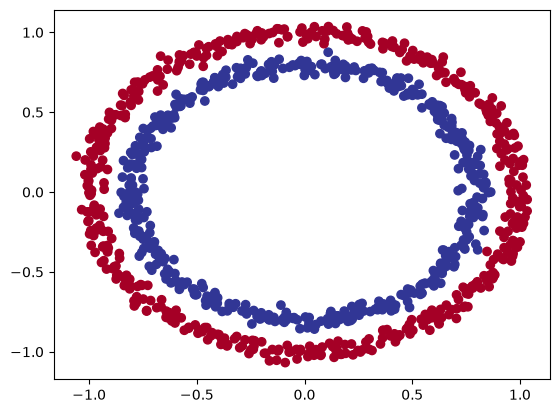

In [29]:
plt.scatter(x=X[:, 0], 
            y=X[:, 1], 
            c=y, 
            cmap=plt.cm.RdYlBu);

In [22]:
X.shape, y.shape

((1000, 2), (1000,))

In [23]:
type(X)

numpy.ndarray

In [24]:
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    )
print(len(X_train), len(X_test), len(y_train), len(y_test))

800 200 800 200


In [26]:
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()